In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K


# --------------------------------------------------------
# 1️⃣ Define Custom L2 Normalization Layer
# --------------------------------------------------------
class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config


# OPTIONAL: If your models include projection head or stop-gradient functions
# you can define placeholders (they are often identity layers in SSL)

class IdentityLayer(Layer):
    def call(self, x):
        return x


custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}

2025-12-14 18:13:46.575524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765736026.908852      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765736027.008801      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import os

base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"

simclr_path = os.path.join(base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path = os.path.join(base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path = os.path.join(base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("Loading SSL Models with custom layers...")

simclr_model = tf.keras.models.load_model(simclr_path, custom_objects=custom_objects)
simsam_model = tf.keras.models.load_model(simsam_path, custom_objects=custom_objects)
barlow_model = tf.keras.models.load_model(barlow_path, custom_objects=custom_objects)

print("✅ All SSL models loaded successfully!")

Loading SSL Models with custom layers...


I0000 00:00:1765736050.168939      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ All SSL models loaded successfully!


In [3]:
#Setup + paths (auto-detect train/test folders)
import os, glob, json, math, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TF:", tf.__version__)


TF: 2.18.0


In [4]:
# ========= USER PATHS =========
SSL_BASE_DIR = "/kaggle/input/alzeihmer-disease-model/other/default/1"
DATASET_ROOT = "/kaggle/input/alzheimer-disease"

simclr_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("SSL model paths:")
print(simclr_path)
print(simsam_path)
print(barlow_path)

# ========= AUTO-FIND train/test directories =========
CLASSES = ["AD", "CN", "MCI"]  # keep your order consistent everywhere

def find_split_dir(root, split_name="train"):
    """
    Finds a directory that contains subfolder `split_name` and inside it the class folders.
    Works for structures like:
      /kaggle/input/alzheimer-disease/train-.../train/AD ...
      /kaggle/input/alzheimer-disease/test-.../test/AD ...
    """
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        base = os.path.basename(dirpath).lower()
        if base == split_name.lower():
            # check classes exist
            ok = all(os.path.isdir(os.path.join(dirpath, c)) for c in CLASSES)
            if ok:
                candidates.append(dirpath)
    # pick shortest (closest to root) if multiple
    candidates = sorted(candidates, key=lambda p: len(p))
    return candidates[0] if candidates else None

train_dir = find_split_dir(DATASET_ROOT, "train")
test_dir  = find_split_dir(DATASET_ROOT, "test")

print("Resolved train_dir:", train_dir)
print("Resolved test_dir :", test_dir)

assert train_dir is not None, "Could not find a valid train/ directory containing AD,CN,MCI."
assert test_dir  is not None, "Could not find a valid test/ directory containing AD,CN,MCI."


SSL model paths:
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_2 SimCLRmodel.h5
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_3 -Simsiammodel.h5
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_4- Barlow twinsmodel.h5
Resolved train_dir: /kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train
Resolved test_dir : /kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test


In [5]:
#Data loaders (train/val/test) – stable & reproducible
IMG_SIZE = (224, 224)  
BATCH_SIZE = 32

def make_ds(directory, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED
    )
    return ds

train_full = make_ds(train_dir, shuffle=True)
test_ds    = make_ds(test_dir, shuffle=False)

# split train -> train/val
VAL_FRAC = 0.2
card = tf.data.experimental.cardinality(train_full).numpy()
val_batches = max(1, int(card * VAL_FRAC))
train_batches = card - val_batches

val_ds   = train_full.take(val_batches)
train_ds = train_full.skip(val_batches)

print("Batches - train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())

# normalization (0..1)
norm = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


Found 4123 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.
Batches - train: 104 val: 25 test: 33


In [6]:
#Defining the L2 Normalization
import tensorflow as tf
from tensorflow import keras

@keras.utils.register_keras_serializable(package="Custom")
class L2Normalization(keras.layers.Layer):
    def __init__(self, axis=-1, epsilon=1e-12, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.epsilon = epsilon

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis, epsilon=self.epsilon)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"axis": self.axis, "epsilon": self.epsilon})
        return cfg


In [7]:
#Loading Models 
import os
import tensorflow as tf

SSL_BASE_DIR = "/kaggle/input/alzeihmer-disease-model/other/default/1"

simclr_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_4- Barlow twinsmodel.h5")

custom_objects = {
    "L2Normalization": L2Normalization,
}

print("Loading SSL Models with custom_object_scope...")

with keras.utils.custom_object_scope(custom_objects):
    simclr_model = tf.keras.models.load_model(simclr_path, compile=False)
    simsam_model = tf.keras.models.load_model(simsam_path, compile=False)
    barlow_model = tf.keras.models.load_model(barlow_path, compile=False)

print(" All SSL models loaded successfully!")


Loading SSL Models with custom_object_scope...
 All SSL models loaded successfully!


In [8]:
#Build Encoders from SSL Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def make_encoder(ssl_model):
    """
    Robustly extracts an encoder from an SSL model.
    Priority:
    1. Known encoder/backbone layer names
    2. Second last layer (typical SSL practice)
    """
    preferred_names = [
        "encoder", "backbone", "base_encoder",
        "feature_extractor", "resnet", "convnext"
    ]

    for name in preferred_names:
        try:
            layer = ssl_model.get_layer(name)
            print(f"Using encoder layer: {name}")
            return keras.Model(
                inputs=ssl_model.input,
                outputs=layer.output,
                name=f"{ssl_model.name}_{name}"
            )
        except:
            pass

    # Fallback → second last layer
    print(" Encoder not explicitly found → using fallback (2nd last layer)")
    output = ssl_model.layers[-2].output
    return keras.Model(
        inputs=ssl_model.input,
        outputs=output,
        name=f"{ssl_model.name}_encoder_fallback"
    )


enc_simclr  = make_encoder(simclr_model)
enc_simsam  = make_encoder(simsam_model)
enc_barlow  = make_encoder(barlow_model)

print("Encoder outputs:")
print("SimCLR :", enc_simclr.output_shape)
print("SimSiam:", enc_simsam.output_shape)
print("Barlow :", enc_barlow.output_shape)


 Encoder not explicitly found → using fallback (2nd last layer)
 Encoder not explicitly found → using fallback (2nd last layer)
 Encoder not explicitly found → using fallback (2nd last layer)
Encoder outputs:
SimCLR : (None, 256)
SimSiam: (None, 256)
Barlow : (None, 256)


In [9]:
#Dataset Pipeline (Train / Val / Test)
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASSES = ["AD", "CN", "MCI"]

train_ds_full = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode="int",
    shuffle=False
)

# Train/Val split
val_fraction = 0.2
total_batches = tf.data.experimental.cardinality(train_ds_full).numpy()
val_batches = int(total_batches * val_fraction)

val_ds   = train_ds_full.take(val_batches)
train_ds = train_ds_full.skip(val_batches)

# Normalization
normalizer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)

print("Dataset ready ")


Found 4123 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.
Dataset ready 


In [10]:
#LARS Optimizer (Safe Fallback)
def get_optimizer(name="lars", lr=1e-3):
    name = name.lower()
    if name == "lars":
        try:
            import tensorflow_addons as tfa
            print("Using LARS optimizer")
            return tfa.optimizers.LARS(learning_rate=lr, momentum=0.9)
        except:
            print(" LARS unavailable → falling back to Adam")
            return keras.optimizers.Adam(learning_rate=lr)
    elif name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        return keras.optimizers.Adam(learning_rate=lr)


In [11]:
#Downstream Classifier Head
NUM_CLASSES = len(CLASSES)

def build_downstream_model(encoder, trainable=False, dropout=0.3):
    encoder.trainable = trainable

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = encoder(inputs)

    # Handle spatial / vector outputs
    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"downstream_{encoder.name}")
    return model


In [12]:
#Train Downstream Models (SimCLR / SimSiam / Barlow)
EPOCHS = 30
LR = 1e-3
OPT = "lars"

models = {}
histories = {}

for name, encoder in {
    "SimCLR": enc_simclr,
    "SimSiam": enc_simsam,
    "BarlowTwins": enc_barlow
}.items():

    print(f"\n==== Training downstream: {name} ====")

    model = build_downstream_model(encoder, trainable=False)

    model.compile(
        optimizer=get_optimizer(OPT, LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=2)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    models[name] = model
    histories[name] = history



==== Training downstream: SimCLR ====
 LARS unavailable → falling back to Adam
Epoch 1/30


I0000 00:00:1765736111.506364      90 service.cc:148] XLA service 0x7a05d40024c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765736111.507884      90 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765736116.333346      90 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/104 ━━━━━━━━━━━━━━━━━━━━ 1:40:25 58s/step - accuracy: 0.3438 - loss: 1.1692

I0000 00:00:1765736138.044637      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


104/104 ━━━━━━━━━━━━━━━━━━━━ 103s 428ms/step - accuracy: 0.4373 - loss: 1.1725 - val_accuracy: 0.2763 - val_loss: 1.1192 - learning_rate: 0.0010
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5042 - loss: 1.0337 - val_accuracy: 0.4925 - val_loss: 1.0644 - learning_rate: 0.0010
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.5107 - loss: 1.0018 - val_accuracy: 0.5325 - val_loss: 0.9704 - learning_rate: 0.0010
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.5739 - loss: 0.8932 - val_accuracy: 0.4837 - val_loss: 1.0421 - learning_rate: 0.0010
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.6261 - loss: 0.8057 - val_accuracy: 0.4825 - val_loss: 1.1885 - learning_rate: 0.0010
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.6743 - loss: 0.7391 - val_accuracy: 0.7075 - val_loss: 0.6250 - learning_rate: 1.0000e-04
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.7513 - 


SimCLR Accuracy: 0.9661
              precision    recall  f1-score   support

          AD       0.97      0.92      0.95       225
          CN       0.93      0.95      0.94       288
         MCI       0.99      0.99      0.99       518

    accuracy                           0.97      1031
   macro avg       0.96      0.96      0.96      1031
weighted avg       0.97      0.97      0.97      1031



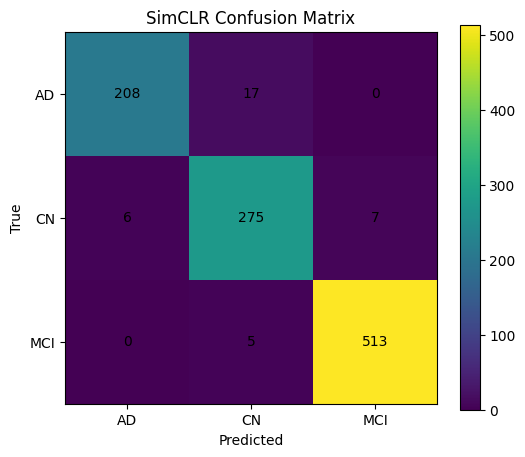


SimSiam Accuracy: 0.9796
              precision    recall  f1-score   support

          AD       0.93      1.00      0.96       225
          CN       0.99      0.98      0.98       288
         MCI       1.00      0.97      0.99       518

    accuracy                           0.98      1031
   macro avg       0.97      0.98      0.98      1031
weighted avg       0.98      0.98      0.98      1031



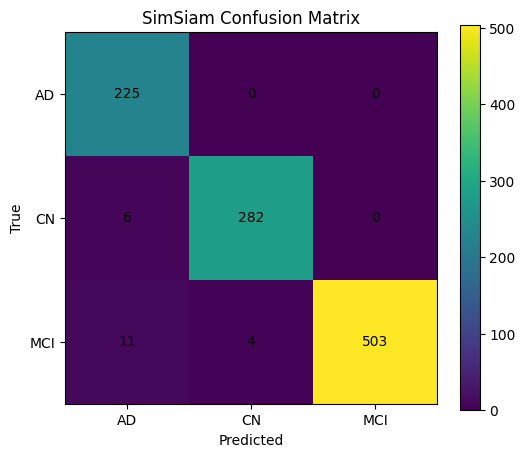


BarlowTwins Accuracy: 0.9641
              precision    recall  f1-score   support

          AD       0.98      0.96      0.97       225
          CN       0.90      0.98      0.94       288
         MCI       1.00      0.96      0.98       518

    accuracy                           0.96      1031
   macro avg       0.96      0.97      0.96      1031
weighted avg       0.97      0.96      0.96      1031



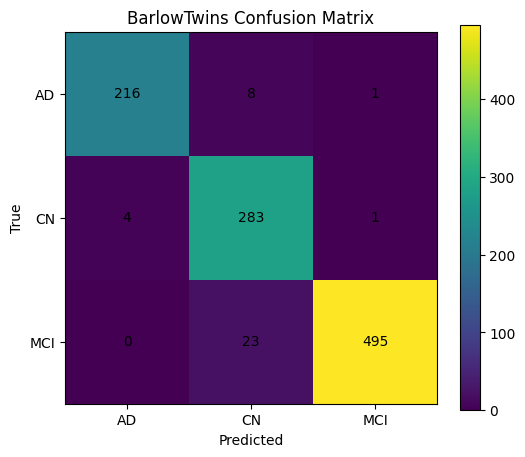

In [13]:
#Evaluation + Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

results = {}

def evaluate(model, ds, name):
    y_true, y_pred = [], []

    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_pred.append(np.argmax(p, axis=1))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(3), CLASSES)
    plt.yticks(range(3), CLASSES)

    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc

for name, model in models.items():
    results[name] = evaluate(model, test_ds, name)


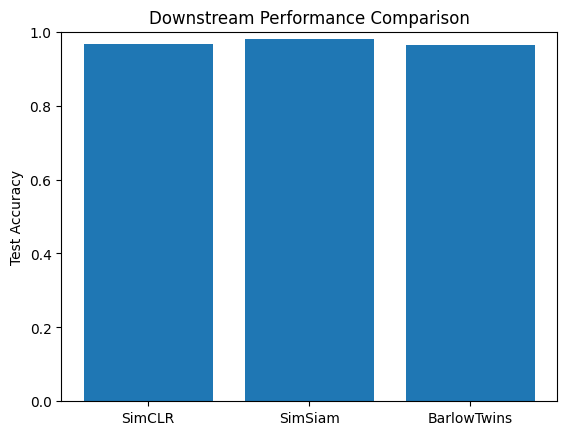

In [14]:
#Downstream Comparison Graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.ylabel("Test Accuracy")
plt.title("Downstream Performance Comparison")
plt.ylim(0, 1)
plt.show()


Using images: (1031, 224, 224, 3) labels: (1031,)

Computing embeddings for: SimCLR
Feature shape: (1031, 256)


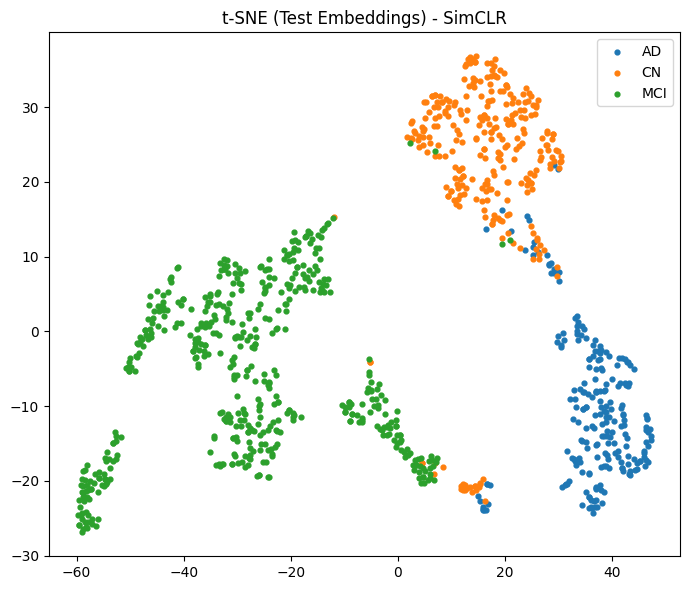


Computing embeddings for: SimSiam
Feature shape: (1031, 256)


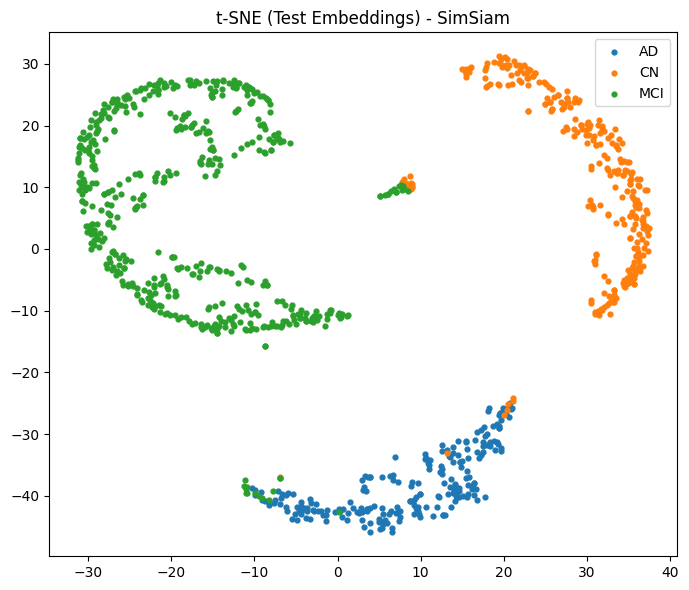


Computing embeddings for: BarlowTwins
Feature shape: (1031, 256)


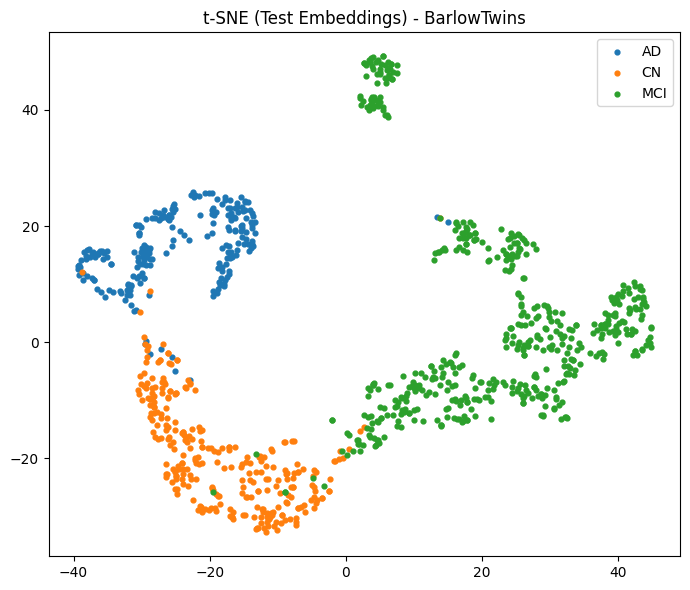

In [15]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Collect a fixed subset of test images ONCE (same samples for all encoders) ---
MAX_BATCHES = 50  # increase if you want more points (may be slower)
Ximg_list, y_list = [], []

for i, (xb, yb) in enumerate(test_ds):
    if i >= MAX_BATCHES:
        break
    Ximg_list.append(xb.numpy())   # xb is already normalized in your pipeline
    y_list.append(yb.numpy())

Ximg = np.concatenate(Ximg_list, axis=0)
y    = np.concatenate(y_list, axis=0)

print("Using images:", Ximg.shape, "labels:", y.shape)

# --- Helper: get embeddings for a given encoder ---
def get_embeddings(encoder, Ximg, batch_size=64):
    feats = []
    for i in range(0, len(Ximg), batch_size):
        xb = Ximg[i:i+batch_size]
        f = encoder(xb, training=False)
        if len(f.shape) == 4:
            f = tf.reduce_mean(f, axis=[1,2])
        feats.append(f.numpy())
    return np.concatenate(feats, axis=0)

encoders = {
    "SimCLR": enc_simclr,
    "SimSiam": enc_simsam,
    "BarlowTwins": enc_barlow
}

# --- Run t-SNE for each encoder and plot ---
for name, enc in encoders.items():
    print(f"\nComputing embeddings for: {name}")
    Xfeat = get_embeddings(enc, Ximg, batch_size=64)
    print("Feature shape:", Xfeat.shape)

    # t-SNE (use same settings for fairness)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=SEED,
        init="pca",
        learning_rate="auto"
    )
    Z = tsne.fit_transform(Xfeat)

    plt.figure(figsize=(7,6))
    for ci, cls in enumerate(CLASSES):
        idx = (y == ci)
        plt.scatter(Z[idx, 0], Z[idx, 1], s=12, label=cls)
    plt.title(f"t-SNE (Test Embeddings) - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()



ABLATION for: SimCLR
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 373ms/step - accuracy: 0.5628 - loss: 0.9742 - val_accuracy: 0.2512 - val_loss: 1.0967 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.6854 - loss: 0.7024 - val_accuracy: 0.2688 - val_loss: 1.1900 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.7898 - loss: 0.5345 - val_accuracy: 0.6025 - val_loss: 0.7608 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.8238 - loss: 0.4388 - val_accuracy: 0.7625 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.8819 - loss: 0.3175 - val_accuracy: 0.5000 - val_loss: 1.7414 - learning_rate: 0.0010
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9045 - loss: 0.2703 - val_accuracy: 0.5987 - val_loss: 1.0

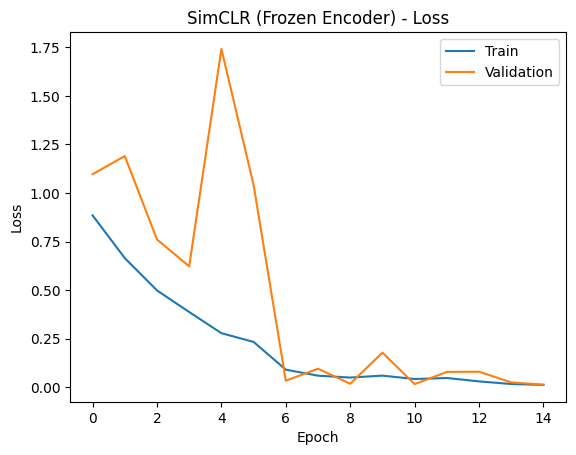

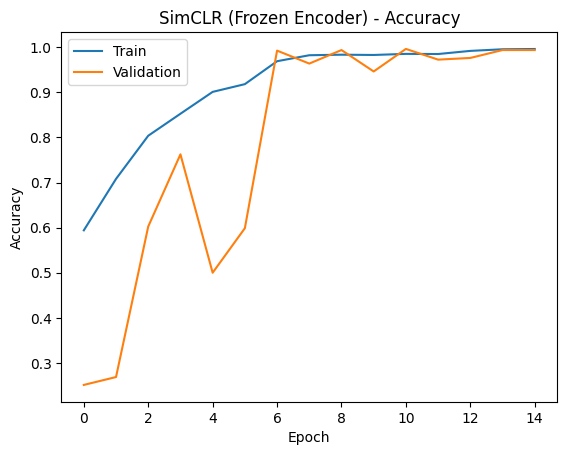

SimCLR Frozen Test Acc = 0.9961
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 376ms/step - accuracy: 0.6870 - loss: 0.7157 - val_accuracy: 0.9950 - val_loss: 0.0206 - learning_rate: 1.0000e-04
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9943 - loss: 0.0532 - val_accuracy: 0.9987 - val_loss: 0.0061 - learning_rate: 1.0000e-04
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9932 - loss: 0.0286 - val_accuracy: 0.9962 - val_loss: 0.0102 - learning_rate: 1.0000e-04
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9968 - loss: 0.0204 - val_accuracy: 0.9987 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9953 - loss: 0.0214 - val_accuracy: 0.9987 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9929 - loss: 0.0322 - val_ac

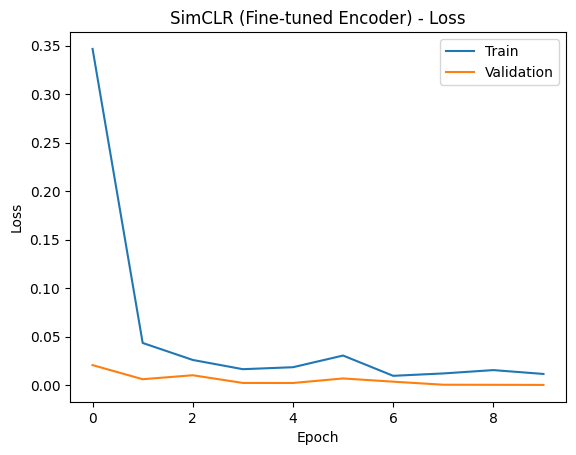

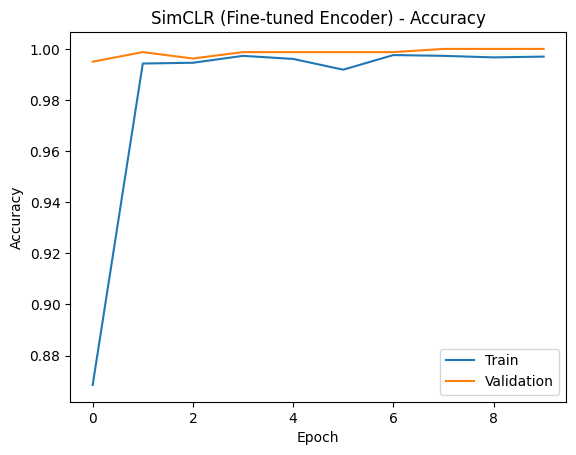

SimCLR Fine-tuned Test Acc = 0.9961

ABLATION for: SimSiam
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 370ms/step - accuracy: 0.5384 - loss: 1.0294 - val_accuracy: 0.4913 - val_loss: 1.1577 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.6788 - loss: 0.7504 - val_accuracy: 0.4900 - val_loss: 2.7440 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.7294 - loss: 0.6063 - val_accuracy: 0.4737 - val_loss: 1.0915 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.7868 - loss: 0.5175 - val_accuracy: 0.5650 - val_loss: 1.7685 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.8306 - loss: 0.4189 - val_accuracy: 0.6212 - val_loss: 0.9518 - learning_rate: 0.0010
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.8655 - loss: 0.3627 -

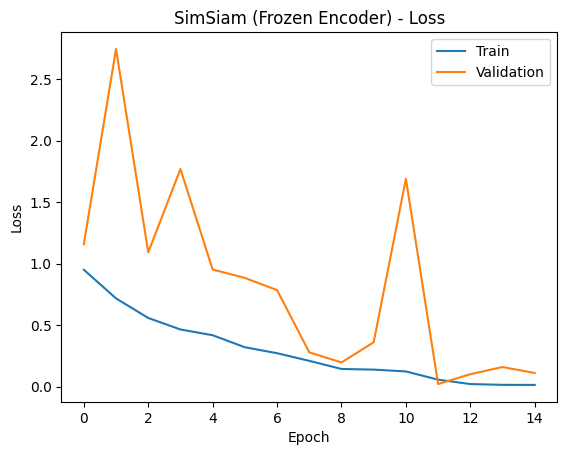

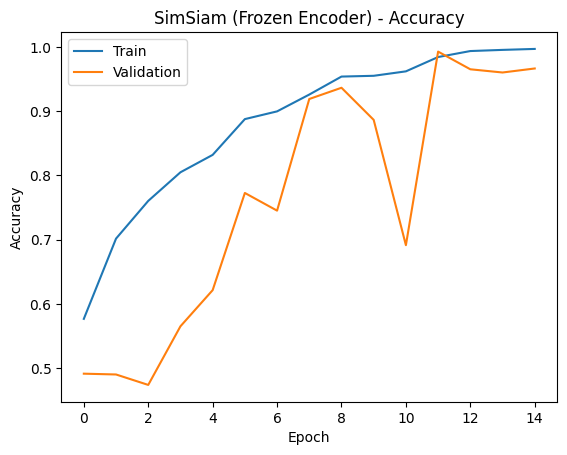

SimSiam Frozen Test Acc = 0.9922
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 377ms/step - accuracy: 0.8002 - loss: 0.4810 - val_accuracy: 0.9987 - val_loss: 0.0184 - learning_rate: 1.0000e-04
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9898 - loss: 0.0506 - val_accuracy: 0.9975 - val_loss: 0.0122 - learning_rate: 1.0000e-04
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9930 - loss: 0.0323 - val_accuracy: 0.9975 - val_loss: 0.0115 - learning_rate: 1.0000e-04
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9952 - loss: 0.0227 - val_accuracy: 0.9950 - val_loss: 0.0230 - learning_rate: 1.0000e-04
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9969 - loss: 0.0144 - val_accuracy: 0.9937 - val_loss: 0.0197 - learning_rate: 1.0000e-04
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9984 - loss: 0.0083 - val_a

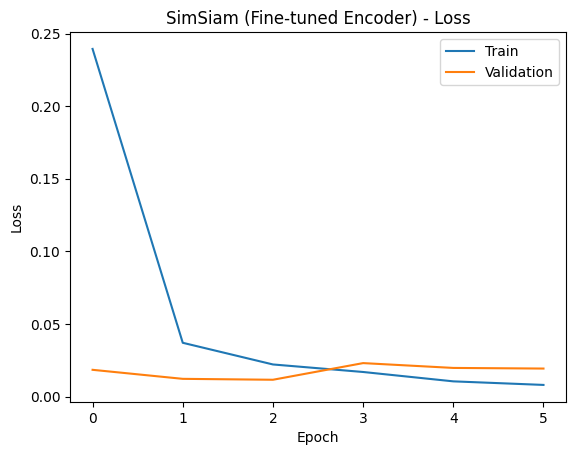

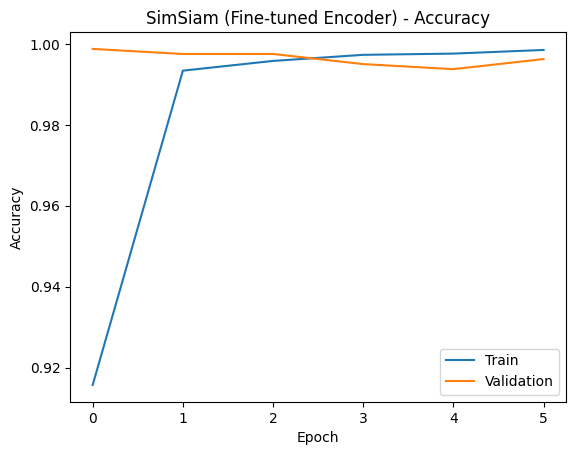

SimSiam Fine-tuned Test Acc = 0.9942

ABLATION for: BarlowTwins
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 87s 371ms/step - accuracy: 0.4869 - loss: 1.0949 - val_accuracy: 0.4900 - val_loss: 1.4906 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.5336 - loss: 0.9675 - val_accuracy: 0.4800 - val_loss: 1.4507 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.5904 - loss: 0.8743 - val_accuracy: 0.4750 - val_loss: 2.2948 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.6476 - loss: 0.7829 - val_accuracy: 0.4500 - val_loss: 2.6225 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.7491 - loss: 0.6448 - val_accuracy: 0.3950 - val_loss: 1.7651 - learning_rate: 5.0000e-04
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.8185 - loss:

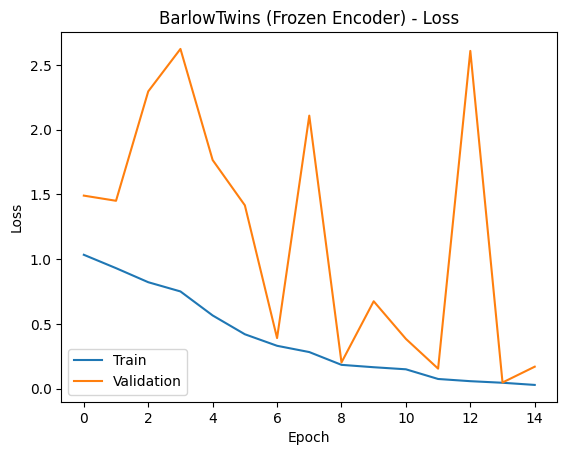

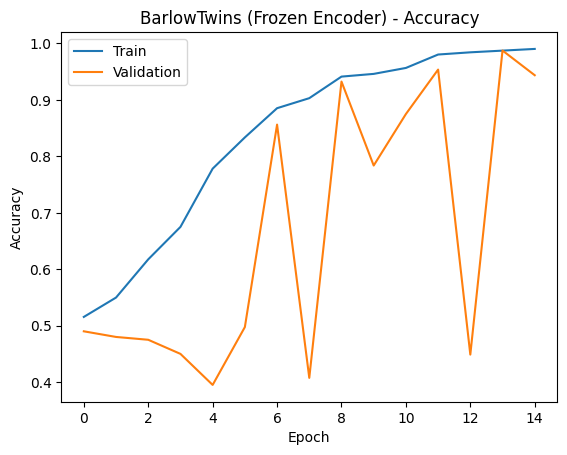

BarlowTwins Frozen Test Acc = 0.9835
 LARS unavailable -> Adam fallback: No module named 'tensorflow_addons' ...
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 382ms/step - accuracy: 0.7362 - loss: 0.6250 - val_accuracy: 0.9950 - val_loss: 0.0268 - learning_rate: 1.0000e-04
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9930 - loss: 0.0447 - val_accuracy: 0.9937 - val_loss: 0.0231 - learning_rate: 1.0000e-04
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9909 - loss: 0.0431 - val_accuracy: 0.9675 - val_loss: 0.0946 - learning_rate: 1.0000e-04
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9927 - loss: 0.0359 - val_accuracy: 0.9987 - val_loss: 0.0051 - learning_rate: 1.0000e-04
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9960 - loss: 0.0194 - val_accuracy: 0.9962 - val_loss: 0.0058 - learning_rate: 1.0000e-04
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9921 - loss: 0.0336 - v

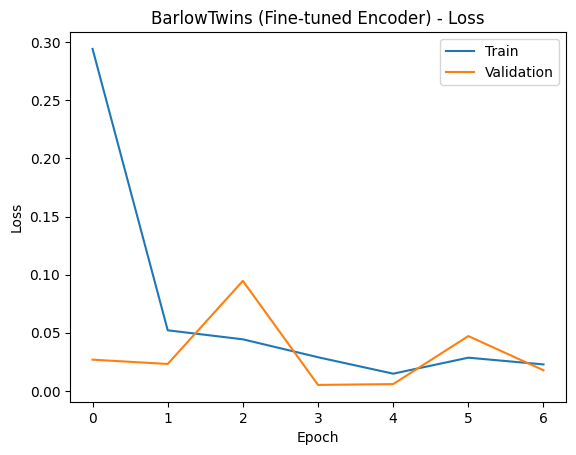

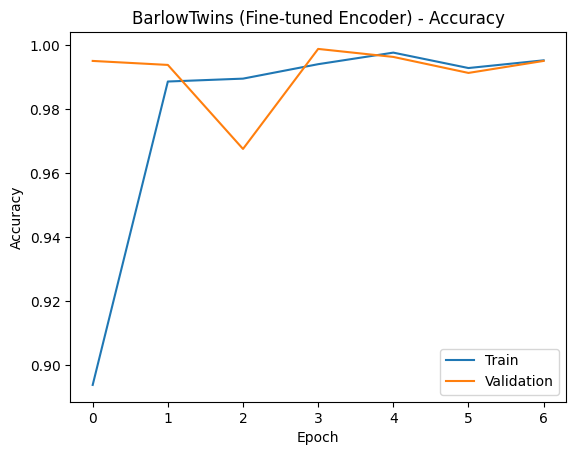

BarlowTwins Fine-tuned Test Acc = 0.9903


,Method,Frozen Acc,Fine-tuned Acc,Δ Acc (FT-Frozen)
0,SimCLR,0.996120,0.996120,0.00000
1,SimSiam,0.992241,0.994180,0.00194
2,BarlowTwins,0.983511,0.990301,0.00679


In [16]:
#FULL ABLATION + STATS + GRADCAM (ALL 3 MODELS)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# 0) Small utilities
# -----------------------------
def plot_history(history, title):
    h = history.history

    plt.figure()
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


def unfreeze_last_layers(model, n=20):
    model.trainable = True
    if n is None:
        return
    for layer in model.layers[:-n]:
        layer.trainable = False


def get_optimizer(name="lars", lr=1e-3):
    name = name.lower()
    if name == "lars":
        try:
            import tensorflow_addons as tfa
            return tfa.optimizers.LARS(learning_rate=lr, momentum=0.9)
        except Exception as e:
            print(" LARS unavailable -> Adam fallback:", str(e)[:120], "...")
            return keras.optimizers.Adam(learning_rate=lr)
    elif name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        return keras.optimizers.Adam(learning_rate=lr)


def build_downstream_model(encoder, trainable=False, dropout=0.3):
    encoder.trainable = trainable
    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x = encoder(inp)
    # If spatial -> GAP (not your case now, but safe)
    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(len(CLASSES), activation="softmax")(x)
    return keras.Model(inp, out, name=f"downstream_{encoder.name}")


def eval_per_sample(model, ds):
    """Return y_true, y_pred, per-sample correctness vector (0/1), accuracy."""
    y_true, y_pred = [], []
    for xb, yb in ds:
        p = model.predict(xb, verbose=0)
        y_true.append(yb.numpy())
        y_pred.append(np.argmax(p, axis=1))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    correct = (y_pred == y_true).astype(np.int32)
    acc = correct.mean()
    return y_true, y_pred, correct, acc


# -----------------------------
# 1) IMPORTANT: clone encoders safely
#    so fine-tuning one does NOT change the others
# -----------------------------
def clone_model_with_weights(m):
    """Clones a keras model architecture + copies weights."""
    cm = keras.models.clone_model(m)
    cm.set_weights(m.get_weights())
    return cm


def make_encoder_smart(ssl_model):
    """Use layer before L2Normalization if present; else fallback to second last layer."""
    names = [l.name.lower() for l in ssl_model.layers]

    # pre-L2Normalization
    for i, n in enumerate(names):
        if "l2normal" in n or "l2_normal" in n:
            if i > 0:
                return keras.Model(ssl_model.input, ssl_model.layers[i-1].output,
                                  name=f"{ssl_model.name}_enc_preL2")

    # fallback
    return keras.Model(ssl_model.input, ssl_model.layers[-2].output,
                      name=f"{ssl_model.name}_enc_fallback")


# -----------------------------
# 2) Run ablation for all 3
# -----------------------------
AB_EPOCHS_FROZEN = 15
AB_EPOCHS_FT     = 10

HEAD_LR = 1e-3
FT_LR   = 1e-4
OPTIM   = "lars"

ssl_original = {
    "SimCLR": simclr_model,
    "SimSiam": simsam_model,
    "BarlowTwins": barlow_model
}

ablation_rows = []
ablation_models = {}  # store models for grad-cam later if needed

# We'll also keep per-sample correctness vectors to do paired t-test
correct_vectors = {}

for method, ssl_m in ssl_original.items():
    print("\n" + "="*70)
    print(f"ABLATION for: {method}")
    print("="*70)

    # clone SSL model (prevents weight contamination)
    ssl_clone = clone_model_with_weights(ssl_m)
    encoder = make_encoder_smart(ssl_clone)

    # ----- Frozen training -----
    frozen_model = build_downstream_model(encoder, trainable=False)
    frozen_model.compile(
        optimizer=get_optimizer(OPTIM, HEAD_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    frozen_hist = frozen_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=AB_EPOCHS_FROZEN,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )

    plot_history(frozen_hist, f"{method} (Frozen Encoder)")

    y_true, y_pred, correct_frozen, acc_frozen = eval_per_sample(frozen_model, test_ds)
    print(f"{method} Frozen Test Acc = {acc_frozen:.4f}")

    # ----- Fine-tuning training -----
    # Unfreeze last N encoder layers
    unfreeze_last_layers(encoder, n=20)

    ft_model = build_downstream_model(encoder, trainable=True)
    ft_model.compile(
        optimizer=get_optimizer(OPTIM, FT_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    ft_hist = ft_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=AB_EPOCHS_FT,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )

    plot_history(ft_hist, f"{method} (Fine-tuned Encoder)")

    y_true2, y_pred2, correct_ft, acc_ft = eval_per_sample(ft_model, test_ds)
    print(f"{method} Fine-tuned Test Acc = {acc_ft:.4f}")

    # store
    correct_vectors[method] = {"frozen": correct_frozen, "finetuned": correct_ft}
    ablation_models[method] = {"frozen": frozen_model, "finetuned": ft_model}

    ablation_rows.append({
        "Method": method,
        "Frozen Acc": acc_frozen,
        "Fine-tuned Acc": acc_ft,
        "Δ Acc (FT-Frozen)": acc_ft - acc_frozen
    })

# -----------------------------
# 3) Ablation Table
# -----------------------------
ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df.sort_values("Fine-tuned Acc", ascending=False).reset_index(drop=True)
display(ablation_df)


In [17]:
from scipy.stats import ttest_rel

stats_rows = []
for method in correct_vectors.keys():
    a = correct_vectors[method]["frozen"]
    b = correct_vectors[method]["finetuned"]

    # paired t-test on per-sample correctness
    t_stat, p_val = ttest_rel(b, a)  # b (fine-tuned) vs a (frozen)

    stats_rows.append({
        "Method": method,
        "t-stat": float(t_stat),
        "p-value": float(p_val),
        "Significant (p<0.05)": (p_val < 0.05)
    })

stats_df = pd.DataFrame(stats_rows).sort_values("p-value")
display(stats_df)


,Method,t-stat,p-value,Significant (p<0.05)
2,BarlowTwins,1.699303,0.089564,False
1,SimSiam,0.706935,0.479767,False
0,SimCLR,0.000000,1.000000,False


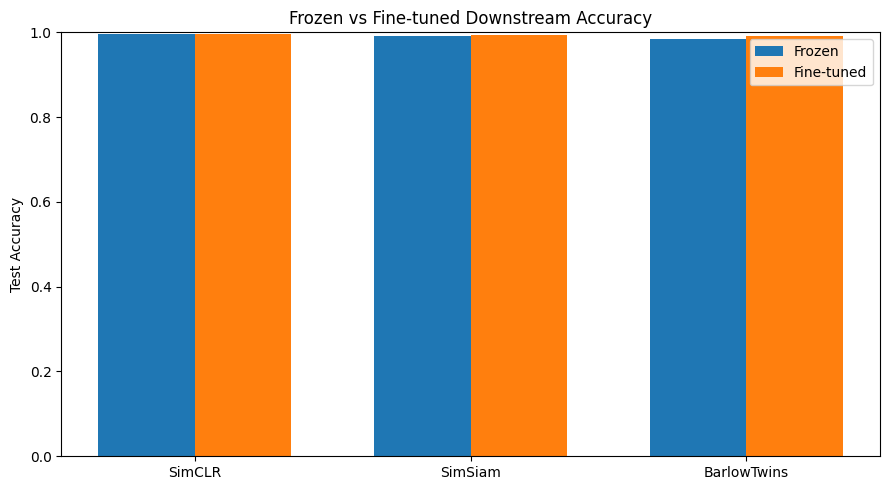

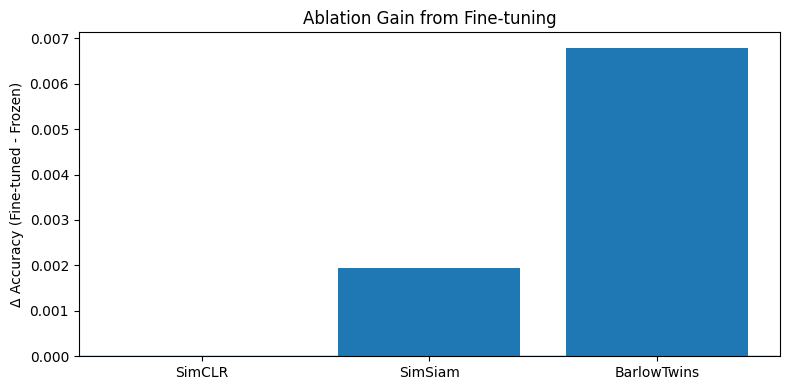

In [18]:
# Bar chart: Frozen vs Fine-tuned (grouped)
methods = ablation_df["Method"].tolist()
frozen_acc = ablation_df["Frozen Acc"].tolist()
ft_acc = ablation_df["Fine-tuned Acc"].tolist()
delta = ablation_df["Δ Acc (FT-Frozen)"].tolist()

x = np.arange(len(methods))
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - w/2, frozen_acc, width=w, label="Frozen")
plt.bar(x + w/2, ft_acc, width=w, label="Fine-tuned")
plt.xticks(x, methods)
plt.ylim(0, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Frozen vs Fine-tuned Downstream Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Ablation graph: Delta accuracy
plt.figure(figsize=(8,4))
plt.bar(methods, delta)
plt.axhline(0, linewidth=1)
plt.ylabel("Δ Accuracy (Fine-tuned - Frozen)")
plt.title("Ablation Gain from Fine-tuning")
plt.tight_layout()
plt.show()


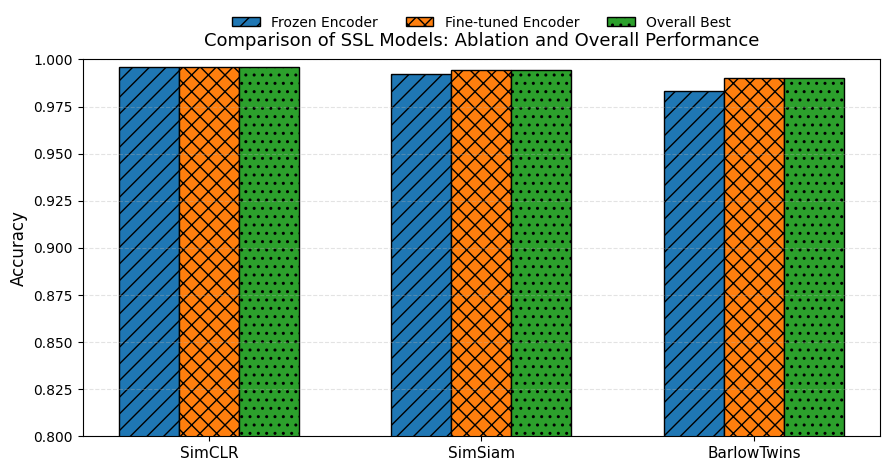

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
methods = ablation_df["Method"].tolist()
frozen_acc = ablation_df["Frozen Acc"].values
finetuned_acc = ablation_df["Fine-tuned Acc"].values
overall_acc = np.maximum(frozen_acc, finetuned_acc)

x = np.arange(len(methods))
width = 0.22

# -----------------------------
# Figure
# -----------------------------
plt.figure(figsize=(9, 4.8))

plt.bar(
    x - width,
    frozen_acc,
    width=width,
    label="Frozen Encoder",
    hatch="//",
    edgecolor="black",
    linewidth=1
)

plt.bar(
    x,
    finetuned_acc,
    width=width,
    label="Fine-tuned Encoder",
    hatch="xx",
    edgecolor="black",
    linewidth=1
)

plt.bar(
    x + width,
    overall_acc,
    width=width,
    label="Overall Best",
    hatch="..",
    edgecolor="black",
    linewidth=1
)

# -----------------------------
# Axis & styling
# -----------------------------
plt.xticks(x, methods, fontsize=11)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.8, 1.0)   # tighten range for clarity (medical papers often do this)

plt.title(
    "Comparison of SSL Models: Ablation and Overall Performance",
    fontsize=13,
    pad=10
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()
